In [68]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [69]:

df = pd.read_csv('/content/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [70]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [71]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['charges'] < lower) | (df['charges'] > upper)]

print(outliers)

      age     sex     bmi  children smoker     region      charges
14     27    male  42.130         0    yes  southeast  39611.75770
19     30    male  35.300         0    yes  southwest  36837.46700
23     34  female  31.920         1    yes  northeast  37701.87680
29     31    male  36.300         2    yes  southwest  38711.00000
30     22    male  35.600         0    yes  southwest  35585.57600
...   ...     ...     ...       ...    ...        ...          ...
1300   45    male  30.360         0    yes  southeast  62592.87309
1301   62    male  30.875         3    yes  northwest  46718.16325
1303   43    male  27.800         0    yes  southwest  37829.72420
1313   19  female  34.700         2    yes  southwest  36397.57600
1323   42  female  40.370         2    yes  southeast  43896.37630

[139 rows x 7 columns]


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [73]:
df.isnull().sum().sum()

np.int64(0)

In [74]:
print(df.duplicated().sum())
df = df.drop_duplicates()

1


In [75]:
df.shape

(1337, 7)

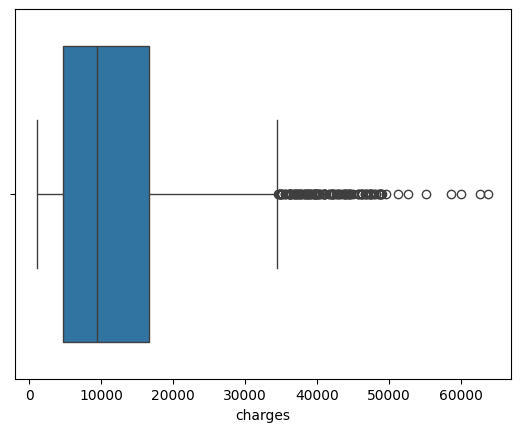

In [76]:
import  seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['charges'])
plt.show()

In [77]:

# PHASE 1: Target & Feature Selection


median_charge = df['charges'].median()
df['high_risk'] = (df['charges'] > median_charge).astype(int)


target_column_class = 'high_risk'
target_column_reg = 'charges'




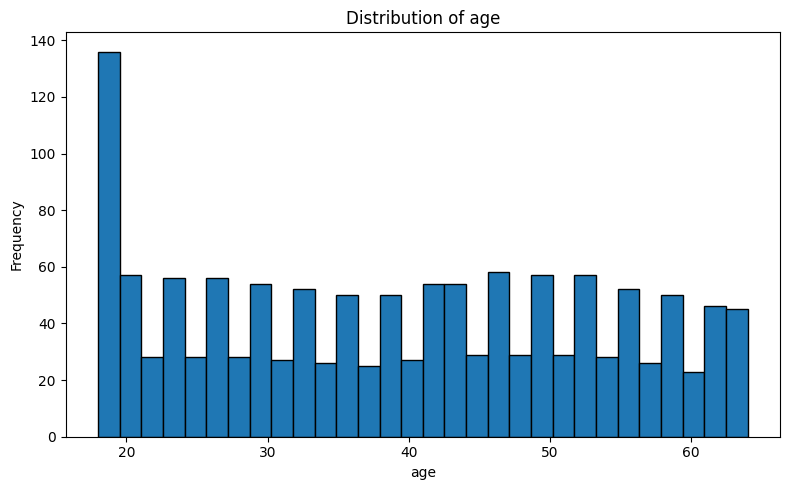

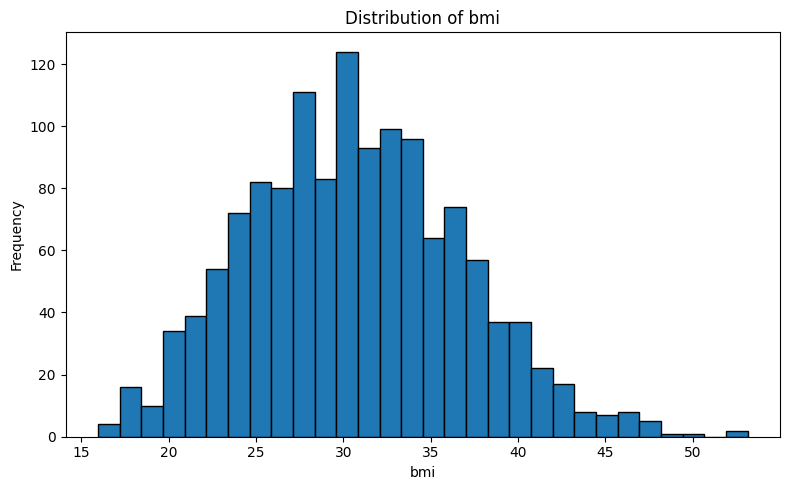

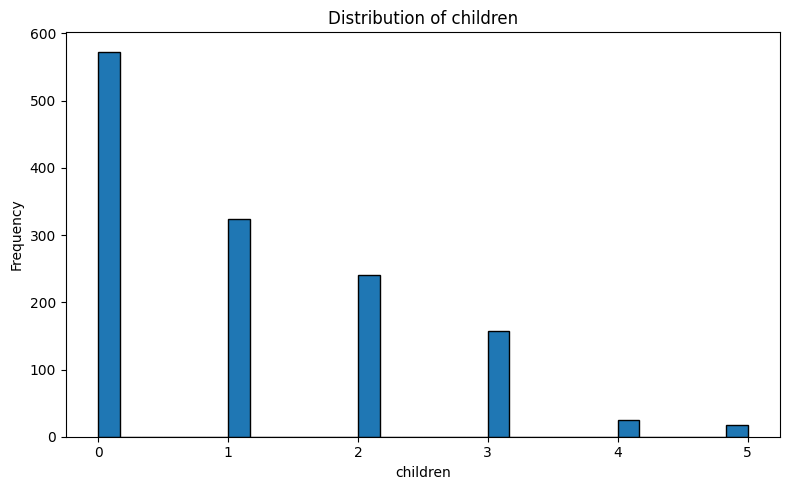

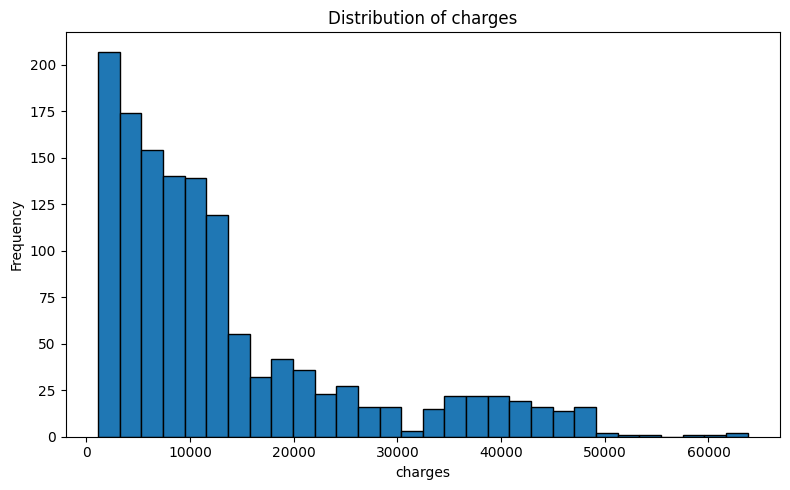

In [103]:
import matplotlib.pyplot as plt

numerical_columns = [
    'age',
    'bmi',
    'children',
    'charges'
]

for column in numerical_columns:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[column],
        bins=30,
        edgecolor='black'
    )

    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')

    plt.tight_layout()
    plt.show()

In [78]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split





X = df.drop(columns=[target_column_class, target_column_reg])
y_class = df[target_column_class]
y_reg = df[target_column_reg]
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_class,
    y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class

)


numerical_features = [
    'age',
    'bmi',
    'children'
]

categorical_features = [
    'sex',
    'smoker',
    'region'
]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])



In [95]:

# PHASE 3: Model Training

lin_reg = LinearRegression()
pipe_reg  = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lin_reg)
])
pipe_reg.fit(X_train, y_reg_train)

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

trained_models = {}
train_results = {}

for name, model in models.items():
  pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
  pipe.fit(X_train, y_class_train)
  trained_models[name] = pipe
  preds = pipe.predict(X_test)
  train_results[name] = preds



In [96]:

# PHASE 4: Model Evaluation (Metrics & Cross-Validation)

y_pred_reg = pipe_reg.predict(X_test )
reg_mse = mean_squared_error(y_reg_test, y_pred_reg)
reg_r2 = r2_score(y_reg_test, y_pred_reg)

evaluation_metrics = []
for name, preds in train_results.items():
    acc = accuracy_score(y_class_test, preds)
    prec = precision_score(y_class_test, preds, zero_division=0)
    rec = recall_score(y_class_test, preds, zero_division=0)
    f1 = f1_score(y_class_test, preds, zero_division=0)

    evaluation_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

eval_df = pd.DataFrame(evaluation_metrics)

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    cv_scores = cross_val_score(pipe, X_train, y_class_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores.mean()

eval_df['CV Mean Accuracy'] = eval_df['Model'].map(cv_results)



In [97]:
# ============================================================
# PHASE 5: Model Selection & Final Output
# ============================================================

# Select the best classification model
best_model_row = eval_df.loc[eval_df['Accuracy'].idxmax()]

best_model_name = best_model_row['Model']

# trained_models contains the FULL pipeline
best_model_instance = trained_models[best_model_name]


# ============================================================
# Test Sample Prediction
# ============================================================

sample_index = 0

# X_test is a Pandas DataFrame
# Use iloc to select one row while keeping it as a DataFrame
sample_data = X_test.iloc[[sample_index]]

predicted_class = best_model_instance.predict(sample_data)[0]

risk_probability = (
    best_model_instance.predict_proba(sample_data)[0][predicted_class]
    * 100
)

risk_level = "High Risk" if predicted_class == 1 else "Low Risk"


# ============================================================
# Final Output
# ============================================================

print("=" * 60)

print("       📊 Medical Cost & Risk Prediction System")

print("=" * 60)

print("\n--- 1. Linear Regression Results (Cost Prediction) ---")

print(f"• Mean Squared Error (MSE): {reg_mse:.2f}")

print(f"• R2 Score: {reg_r2 * 100:.2f}%")


print("\n--- 2. Classification Models Evaluation & Cross-Validation ---")

print(eval_df.to_string(index=False))


print("\n" + "=" * 60)

print("🏆 Final Selection & System Recommendation")

print("=" * 60)

print(f"• Best Performing Model: [{best_model_name}]")

print(f"• Analyzed Client Status (Sample #{sample_index}):")

print(f"  - Risk Classification: {risk_level}")

print(f"  - Model Confidence: {risk_probability:.2f}%")


print("\n--- 💡 Insurance Company Recommendation ---")

if predicted_class == 1:

    print("⚠️ [Financial Alert]: This client is classified as High Risk.")

    print(
        "   Recommendation: Review the predicted cost and "
        "consider appropriate pricing based on business rules."
    )

else:

    print("✅ [Lower Cost Status]: This client is classified as Low Risk.")

    print(
        "   Recommendation: The client falls into the lower-cost "
        "classification according to the model."
    )


print("=" * 60)


# ============================================================
# TEST NEW DATA
# ============================================================

new_patients_data = pd.DataFrame({

    'age': [25, 45, 35, 52, 28],

    'sex': [
        'male',
        'female',
        'male',
        'female',
        'male'
    ],

    'bmi': [22.5, 31.2, 27.4, 34.0, 24.1],

    'children': [0, 2, 1, 3, 0],

    'smoker': [
        'no',
        'yes',
        'no',
        'yes',
        'no'
    ],

    'region': [
        'northeast',
        'northwest',
        'southeast',
        'northwest',
        'northeast'
    ]
})


# ============================================================
# Predictions
# ============================================================

# Regression Pipeline handles:
# - encoding
# - scaling
# - prediction

new_costs = pipe_reg.predict(new_patients_data)


# Classification Pipeline handles:
# - encoding
# - scaling
# - prediction

new_preds = best_model_instance.predict(new_patients_data)

new_probs = best_model_instance.predict_proba(new_patients_data)


# ============================================================
# Batch Reports
# ============================================================

print("\nBatch System Recommendations & Reports for New Patients:\n")


for i in range(len(new_patients_data)):

    risk_level = (
        "High Risk"
        if new_preds[i] == 1
        else "Low Risk"
    )

    risk_probability = (
        new_probs[i][new_preds[i]] * 100
    )

    print("-" * 60)

    print(f"--- Client Analysis Report [Patient #{i + 1}] ---")

    print(f"Best Performing Model: [{best_model_name}]")

    print(f"Predicted Medical Cost: ${new_costs[i]:,.2f}")

    print(f"Risk Classification: {risk_level}")

    print(f"Model Confidence: {risk_probability:.2f}%")

    print()

    print("Insurance System Recommendation:")

    if new_preds[i] == 1:

        print(
            "[Financial Alert]: This client is classified "
            "as High Risk."
        )

        print(
            "Recommendation: Review the predicted cost "
            "and apply the appropriate pricing/business rules."
        )

    else:

        print(
            "[Lower Cost Status]: This client is classified "
            "as Low Risk."
        )

        print(
            "Recommendation: The client falls into the "
            "lower-cost classification according to the model."
        )

    print()

       📊 Medical Cost & Risk Prediction System

--- 1. Linear Regression Results (Cost Prediction) ---
• Mean Squared Error (MSE): 39258090.56
• R2 Score: 77.51%

--- 2. Classification Models Evaluation & Cross-Validation ---
              Model  Accuracy  Precision   Recall  F1-Score  CV Mean Accuracy
Logistic Regression  0.902985   0.891304 0.917910  0.904412          0.903659
                KNN  0.902985   0.935484 0.865672  0.899225          0.889614
                SVM  0.936567   0.953488 0.917910  0.935361          0.925172
      Decision Tree  0.902985   0.902985 0.902985  0.902985          0.881221
      Random Forest  0.936567   0.960630 0.910448  0.934866          0.924224

🏆 Final Selection & System Recommendation
• Best Performing Model: [SVM]
• Analyzed Client Status (Sample #0):
  - Risk Classification: High Risk
  - Model Confidence: 79.66%

--- 💡 Insurance Company Recommendation ---
⚠️ [Financial Alert]: This client is classified as High Risk.
   Recommendation: Revie

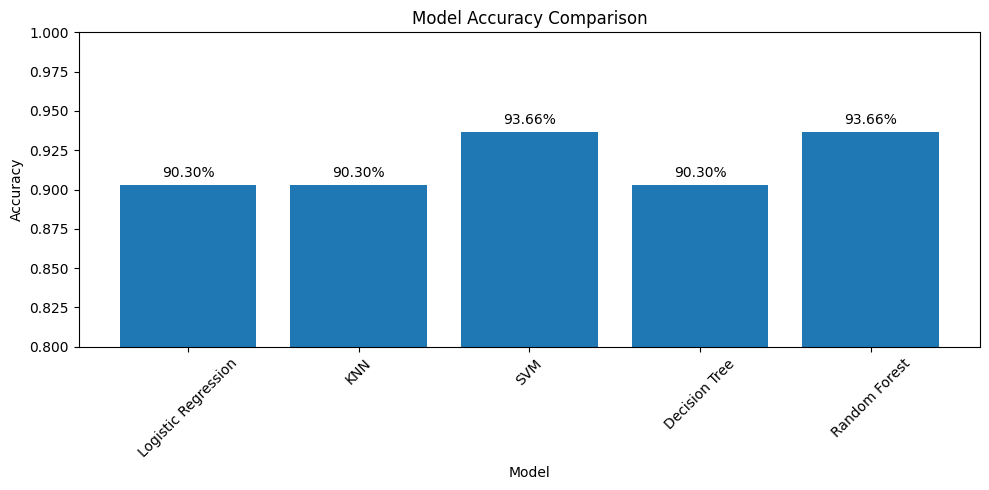

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

bars = plt.bar(
    eval_df['Model'],
    eval_df['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.ylim(0.8, 1.0)
plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{bar.get_height():.2%}",
        ha='center'
    )

plt.tight_layout()
plt.show()

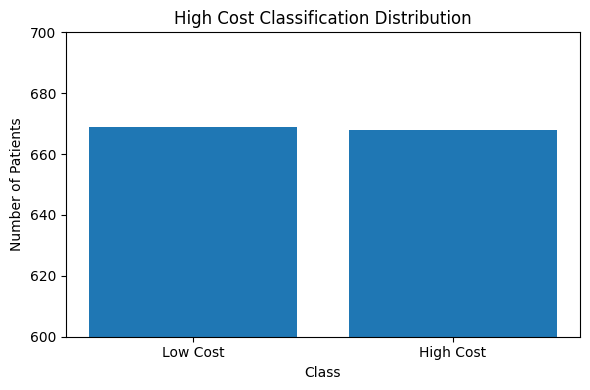

In [105]:
import matplotlib.pyplot as plt

counts = df['high_risk'].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ['Low Cost', 'High Cost'],
    counts.values
)

plt.xlabel('Class')
plt.ylabel('Number of Patients')
plt.title('High Cost Classification Distribution')
plt.ylim(600 , 700)
plt.tight_layout()
plt.show()